## Introduzione

Il dataset utilizzato è una raccolta di immagini (di dimensione $700 \times 700$) aeree sulle torri di trasmissione e sui cavi elettrici. Il dataset è costuito da due insiemi:
- un training set costituito da $842$ immagini
- un test set costituito da $400$ immagini

Ogni sottoinsieme presenta un file JSON in formato COCO contente per ogni immagine, oltre le informazioni relative ad essa, anche le informazioni su etichetta e maschera degli oggetti presenti in essa.

Il formato COCO (Common Objects in Context) è un formato standard per l'archiviazione e la condivisione di annotazioni per immagini e video. Nel formato COCO, le annotazioni vengono archiviate in un file JSON, che contiene informazioni sull'immagine o sul video, inclusi il percorso del file, la dimensione e un elenco di oggetti annotati

```json
{
    "info": {...},
    "licenses": [...],
    "images": [...],
    "annotations": [...],
    "categories": [...], #<-- Not in Captions annotations
    "segment_info": [...] #<-- Only in Panoptic annotations
}
```

Ogni oggetto annotato è identificato da un ID univoco e contiene:
- l'ID dell'immagine a cui si riferisce;
- le informazioni sulla bounding box;
- la categoria dell'oggetto annotato;
- le informazioni sulla segmentazione;
- l'area della bounding box;
- l'attributo "iscrowd", che indica un grande riquadro di delimitazione che circonda più oggetti della stessa categoria utilizzata per la valutazione.

L'obiettivo di questo progetto è quello di costruire un modello in grado di effettuare Object Detection e Image Segmentation su tale dataset al fine di riconoscere e individuare i pixel rappresentanti torri di trasmissioni e cavi elettrici.

## Scelta del modello

Tra i diversi modelli presenti in letteratura si è scelto di utilizzare il modello YOLO; in particolare, è stata utilizzata la versione più recente del modello, ovvero YOLOv8.

YOLO (You Only Look Once) è un algoritmo di rilevamento di oggetti a stadio singolo che utilizza una rete neurale convoluzionale (CNN) per prevedere i riquadri di delimitazione e le probabilità delle classi degli oggetti nelle immagini di input.

L'algoritmo divide l'immagine in input in una griglia di celle e per ciascuna cella prevede la probabilità della presenza di un oggetto e le coordinate del riquadro di delimitazione dell'oggetto. Prevede anche la classe dell'oggetto. A differenza dei rilevatori di oggetti a due stadi come R-CNN e le sue varianti, YOLO elabora l'intera immagine in un unico passaggio, rendendola più veloce ed efficiente.

YOLO è ampiamente utilizzato nei progetti del mondo reale grazie alla sua precisione e velocità; i suoi principali vantaggi sono:

1. Rilevamento di oggetti in tempo reale: YOLO è in grado di rilevare oggetti in tempo reale, rendendolo adatto per applicazioni come la videosorveglianza o le auto a guida autonoma.

2. Elevata precisione: YOLO raggiunge un'elevata precisione utilizzando una rete neurale convoluzionale (CNN) per prevedere sia la classe che la posizione degli oggetti in un'immagine.

3. Rilevamento a scatto singolo: YOLO può rilevare oggetti in un'immagine con un solo passaggio in avanti attraverso la rete, rendendolo più efficiente rispetto ad altri metodi di rilevamento di oggetti che richiedono più passaggi.

4. Buone prestazioni su piccoli oggetti: YOLO è in grado di rilevare piccoli oggetti in un'immagine grazie al suo approccio basato sulla griglia.

5. Uso efficiente delle GPU: YOLO utilizza un'architettura di rete completamente convoluzionale, che consente l'uso efficiente delle GPU durante l'addestramento e l'inferenza.

6. Capacità di gestire più scale: YOLO utilizza scatole di ancoraggio, che consentono al modello di gestire oggetti di scale diverse, consentendo così al modello di rilevare oggetti di dimensioni diverse nella stessa immagine.

Anche se YOLO è un potente algoritmo di rilevamento degli oggetti, presenta anche alcune limitazioni:

1. Limitato al rilevamento di oggetti: YOLO è progettato principalmente per il rilevamento di oggetti e potrebbe non funzionare altrettanto bene su altre attività come la segmentazione di immagini o la segmentazione di istanze.

2. Meno accurato di altri metodi: sebbene YOLO sia accurato, potrebbe non essere accurato quanto i metodi di rilevamento di oggetti a due colpi, come RetinaNet o Mask R-CNN.

3. Problemi con oggetti molto piccoli: l'approccio basato sulla griglia di YOLO può rendere difficile il rilevamento di oggetti minuscoli, soprattutto se si trovano vicino ad altri oggetti.

In [ ]:
!pip install roboflow ultralytics

In [2]:
import ultralytics
from IPython.display import display, Image
from roboflow import Roboflow
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
ultralytics.checks()

Ultralytics YOLOv8.1.17 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16276MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 5432.2/8062.4 GB disk)


Importazione del dataset attraverso Roboflow

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="5wYt3bgWeDxWyNGUF1kw")
project = rf.workspace("computer-vision-lhekh").project("computer-vision-mivrh")
dataset = project.version(3).download("yolov8",location="/content/Computer-Vision-1")

print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.1.17, to fix: `pip install ultralytics==8.0.196`



Extracting Dataset Version Zip to /content/Computer-Vision-1 in yolov8:: 100%|██████████| 2492/2492 [00:00<00:00, 5061.33it/s]

/content/Computer-Vision-1


### YOLOv8

Essendo l'ultima versione dell'algoritmo YOLO, YOLOv8 si basa su tutti gli aspetti positivi delle versioni precedenti, introducendo, però, alcune caratteristiche nuove che lo rendono ancora più efficiente ed efficace. In particolare, YOLOv8 utilizza un'architettura priva di ancoraggi: eliminando la necessità di scatole di ancoraggio predefinite, l'algoritmo si adatta a diverse dimensioni e proporzioni di oggetti in modo più efficace, con conseguente migliore precisione di rilevamento.

Oltre a fornire la possibilità di implementare da zero i propri modelli, YOLOv8 presenta anche una serie di modelli pre-addestrati:

![image.png](attachment:image.png)

La differenza tra tali modelli riguarda principalmente sta nelle dimensione e nel numero di parametri, ovviamente modelli con più parametri tendono ad essere più precisi ma più lenti, al contrario, modelli con meno parametri risultano essere più veloci ma meno precisi.

A tale scopo andiamo ad utilizzare i modelli "YOLOv8s-seg.pt" e "YOLOv8l-seg.pt", in maniera da individuare e mostrare eventuali differenze in termini di efficienza e precisione.

In [4]:
!yolo task=segment mode=train model=yolov8l-seg.pt data={dataset.location}/data.yaml epochs=200 imgsz=640

100%|███████████████████████████████████████| 88.1M/88.1M [00:00<00:00, 293MB/s]
Ultralytics YOLOv8.1.17 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16276MiB)
engine/trainer: task=segment, mode=train, model=yolov8l-seg.pt, data=/content/Computer-Vision-1/data.yaml, epochs=200, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

Una volta addestrato il modello andiamo a fare predizione sul test set e a costruire il file JSON in formato COCO contenente i risultati ottenuti.

Di deafult, YOLO restituisce i risultati nel formato testuale YOLO, ovvero un file .txt per ogni immagine contenente le annotazioni relative alle bounding boxes e le informazioni di segmentazione. In particolare, ogni riga presenta la seguente struttura:

```html
<object_class> <x_center> <y_center> <width> <height> <segmentation_info>
```

Dunque, è stato necessario implementare un algoritmo per restituire i risultati nel formato COCO JSON al posto del formato testuale YOLO.

In [ ]:
model_large = YOLO(model='/kaggle/input/yoloselar/200_lar_train.pt')

In [ ]:
res_yolo = model_large.predict('/kaggle/input/cvdataset/testset/testset', save_txt = True)

In [ ]:
import json

images = {}
with open('kaggle/input/cvdataset/testset/testset/test.json') as json_file:
    data = json.load(json_file)
    for img in data['images']:
        images[img['file_name']] = img['id']

Estraiamo le box e le segmentazioni in formato YOLO, per trasformarle in formato COCO

In [ ]:
import pycocotools.mask as maskUtils
import os

INPUT_DIR = 'kaggle/input/cvdataset/testset/testset/'
ret = []
bad_ann = 0
for filename in os.listdir(INPUT_DIR):
    path = os.path.join(INPUT_DIR, filename)
    if filename != 'test.json':
        result = model_large.predict(path)
        n_detections = len(result[0].boxes.xywh)
        for i in range(n_detections):
            image_id = images[filename]
            category_id = int(result[0].boxes[i].cls.tolist()[0])
            score = float(result[0].boxes[i].conf.tolist()[0])
            bbox = result[0].boxes[i].xywh.tolist()[0]
            bbox[0] = bbox[0] - bbox[2]/2
            bbox[1] = bbox[1] - bbox[3]/2
            segm = [result[0].masks[i].xy[0].flatten().tolist()]
            
            if len(segm[0]) == 0 or len(segm[0]) == 4 or len(segm[0]) == 2:
                bad_ann +=1
                continue
            
            rles = maskUtils.frPyObjects(segm, 700, 700)
            rle = maskUtils.merge(rles)
            rle['counts'] = rle['counts'].decode('ascii')
            ret.append({
                'image_id': image_id,
                'category_id': category_id,
                'bbox': bbox,
                'segmentation': rle,
                'score': score
            })

# Save the COCO dataset to a JSON file
try:
    with open('./annotations_large.json', 'w') as f:
        json.dump(ret, f)
except FileNotFoundError:
    with open('./annotations_large.json', 'x') as f:
        json.dump(ret, f)

### Modello YOLOv8s

In [4]:
!yolo task=segment mode=train model=yolov8s-seg.pt data={dataset.location}/data.yaml epochs=200 imgsz=640

100%|███████████████████████████████████████| 22.8M/22.8M [00:00<00:00, 214MB/s]
Ultralytics YOLOv8.1.16 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16276MiB)
engine/trainer: task=segment, mode=train, model=yolov8s-seg.pt, data=/content/Computer-Vision-1/data.yaml, epochs=200, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_

In [ ]:
model_small = YOLO(model='/kaggle/input/yoloseg/200_epoch_segmentation.pt')

In [ ]:
import json

images = {}
with open('kaggle/input/cvdataset/testset/testset/') as json_file:
    data = json.load(json_file)
    for img in data['images']:
        images[img['file_name']] = img['id']

In [ ]:
import pycocotools.mask as maskUtils
import os

INPUT_DIR =' kaggle/input/cvdataset/testset/testset/'
ret = []
bad_ann = 0
for filename in os.listdir(INPUT_DIR):
    path = os.path.join(INPUT_DIR, filename)
    if filename != 'test.json':
        result = model_small.predict(path)
        n_detections = len(result[0].boxes.xywh)
        for i in range(n_detections):
            image_id = images[filename]
            category_id = int(result[0].boxes[i].cls.tolist()[0])
            score = float(result[0].boxes[i].conf.tolist()[0])
            bbox = result[0].boxes[i].xywh.tolist()[0]
            bbox[0] = bbox[0] - bbox[2]/2
            bbox[1] = bbox[1] - bbox[3]/2
            segm = [result[0].masks[i].xy[0].flatten().tolist()]
            
            if len(segm[0]) == 0 or len(segm[0]) == 4 or len(segm[0]) == 2:
                bad_ann +=1
                continue
            
            rles = maskUtils.frPyObjects(segm, 700, 700)
            rle = maskUtils.merge(rles)
            rle['counts'] = rle['counts'].decode('ascii')
            ret.append({
                'image_id': image_id,
                'category_id': category_id,
                'bbox': bbox,
                'segmentation': rle,
                'score': score
            })

# Save the COCO dataset to a JSON file
try:
    with open('./annotations_small.json', 'w') as f:
        json.dump(ret, f)
except FileNotFoundError:
    with open('./annotations_small.json', 'x') as f:
        json.dump(ret, f)

### Performance

Una volta addestrati e testati entrambi i modelli andiamo a valutarne e confrontarne le performance per scegliere il modello che offre le migliori prestazioni. 

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pathlib import Path
import json

In [ ]:
def evaluate_object_detection(gt_json_path, pred_json_path, check_cable_class=False):
    # Load ground truth and predictions in COCO format
    coco_gt = COCO(gt_json_path)
    coco_pred = coco_gt.loadRes(pred_json_path)

    # Create COCOeval object
    coco_eval = COCOeval(coco_gt, coco_pred, 'bbox')
    if check_cable_class:
        coco_eval.params.catIds = [0]  # id of the cable class

    # Run evaluation
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    avg_p50 = coco_eval.stats[1]
    return avg_p50

def evaluate_segmentation(gt_json_path, pred_json_path, check_cable_class=False):
    # Load ground truth
    coco_gt = COCO(gt_json_path)

    # Load predictions
    with open(pred_json_path, 'r') as f:
        predictions = json.load(f)

    # Load results into COCO results structure
    coco_res = coco_gt.loadRes(predictions)

    # Create COCOeval object
    coco_eval = COCOeval(coco_gt, coco_res, 'segm')
    if check_cable_class:
        coco_eval.params.catIds = [0]  # id of the cable class

    # Run evaluation
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    avg_p50 = coco_eval.stats[1]
    return avg_p50

In [ ]:
gt_json_path = 'kaggle/input/cvdataset/testset/testset/test.json'

In [ ]:
pred_json_path = './annotations_small.json'

evaluate_object_detection(gt_json_path, pred_json_path, False)
print('#'*50)
evaluate_segmentation(gt_json_path, pred_json_path, False)

print('#'*50)
print('#'*50)

evaluate_object_detection(gt_json_path, pred_json_path, True)
print('#'*50)
evaluate_segmentation(gt_json_path, pred_json_path, True)

In [ ]:
pred_json_path = './annotations_large.json'

evaluate_object_detection(gt_json_path, pred_json_path, False)
print('#'*50)
evaluate_segmentation(gt_json_path, pred_json_path, False)

print('#'*50)
print('#'*50)

evaluate_object_detection(gt_json_path, pred_json_path, True)
print('#'*50)
evaluate_segmentation(gt_json_path, pred_json_path, True)

## SAM (Segment Anything Model)

Il Segment Anything Model (SAM) è un modello di rete neurale sviluppato per eseguire la segmentazione semantica. A differenza dei tradizionali modelli di segmentazione semantica che mirano a rilevare e classificare pixel in categorie predefinite, SAM cerca di "segmentare qualsiasi cosa" nell'immagine, inclusi oggetti e classi che potrebbero non essere stati precedentemente identificati.

SAM è progettato per affrontare il problema della segmentazione semantica in scenari in cui la classe di oggetti è estremamente varia o in cui gli oggetti possono essere particolarmente complessi e diversi da quelli presenti nei dataset di addestramento tradizionali.

Per fare ciò, SAM adotta un approccio che utilizza reti neurali convoluzionali adattive e meccanismi di apprendimento senza supervisione. Invece di limitarsi a classificare pixel in categorie predefinite, SAM cerca di creare una rappresentazione densa dell'immagine in cui ogni pixel è associato a una "rappresentazione semantica" che codifica informazioni dettagliate sull'oggetto rappresentato da quel pixel.

Effettuiamo delle predict con YOLO per SAM su una singola immagine

In [5]:
!yolo predict model='/kaggle/working//runs/segment/train/weights/best.pt' source='/kaggle/input/cvdataset/testset/testset'

Ultralytics YOLOv8.1.17 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16276MiB)
YOLOv8l-seg summary (fused): 295 layers, 45914972 parameters, 0 gradients, 220.1 GFLOPs

image 1/400 /kaggle/input/cvdataset/testset/testset/04_2220.jpg: 640x640 4 cables, 30.4ms
image 2/400 /kaggle/input/cvdataset/testset/testset/04_3420.jpg: 640x640 12 cables, 1 tower_wooden, 30.4ms
image 3/400 /kaggle/input/cvdataset/testset/testset/08_1725.jpg: 640x640 6 cables, 1 tower_wooden, 30.5ms
image 4/400 /kaggle/input/cvdataset/testset/testset/1000_00273.jpg: 640x640 16 cables, 1 tower_lattice, 30.4ms
image 5/400 /kaggle/input/cvdataset/testset/testset/1000_00285.jpg: 640x640 11 cables, 1 tower_lattice, 27.9ms
image 6/400 /kaggle/input/cvdataset/testset/testset/1000_00295.jpg: 640x640 11 cables, 1 tower_lattice, 27.8ms
image 7/400 /kaggle/input/cvdataset/testset/testset/1000_00643.jpg: 640x640 14 cables, 1 tower_lattice, 27.7ms
image 8/400 /kaggle/input/cvdataset/testset/testset/103_5565.jpg: 640x6

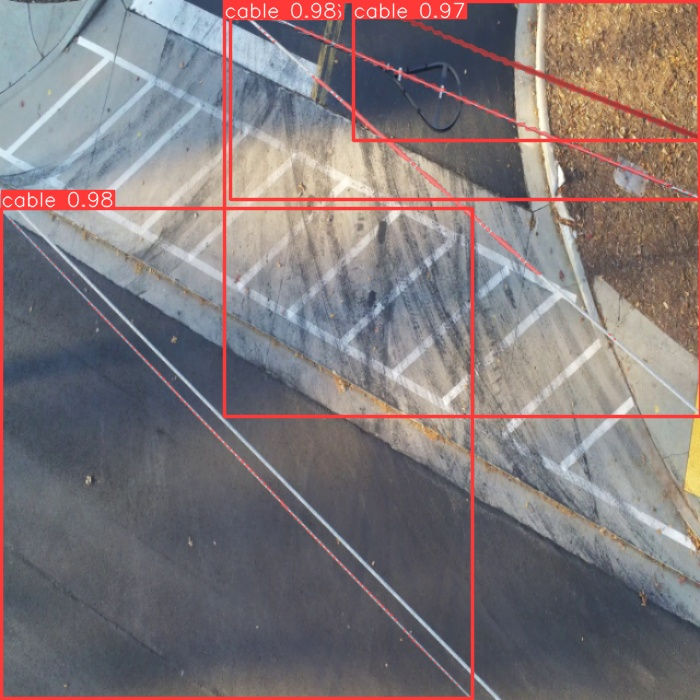

In [6]:
Image(filename='/kaggle/working/runs/segment/predict/04_2220.jpg', height=640)

Proviamo ad effettuare un test con SAM, utilizzando le BBox create con YOLO

In [37]:
from ultralytics import YOLO
model = YOLO('/kaggle/input/yoloseg/200_epoch_segmentation.pt')
results = model.predict(source='/kaggle/input/cvdataset/testset/testset/31_7785.jpg', conf=0.50)



image 1/1 /kaggle/input/cvdataset/testset/testset/31_7785.jpg: 640x640 22 cables, 1 tower_tucohy, 12.9ms
Speed: 2.9ms preprocess, 12.9ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)


estrazione bbox

In [38]:
for result in results:
    boxes = result.boxes  

    bbox=boxes.xyxy.tolist()[1]

In [30]:
image = cv2.cvtColor(cv2.imread('/kaggle/input/cvdataset/testset/testset/1000_00273.jpg'), cv2.COLOR_BGR2RGB)

Importazione modello HQ SAM, 

In [10]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

print("PyTorch version:", torch.__version__)
print("CUDA is available:", torch.cuda.is_available())

!git clone https://github.com/SysCV/sam-hq.git
!pip install timm
os.chdir('sam-hq')
!export PYTHONPATH=$(pwd)
from segment_anything import sam_model_registry, SamPredictor

PyTorch version: 2.1.2
CUDA is available: True
Cloning into 'sam-hq'...
remote: Enumerating objects: 443, done.
remote: Counting objects: 100% (181/181), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 443 (delta 105), reused 75 (delta 65), pack-reused 262
Receiving objects: 100% (443/443), 42.16 MiB | 21.47 MiB/s, done.
Resolving deltas: 100% (202/202), done.


Overwriting tiny_vit_5m_224 in registry with segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
Overwriting tiny_vit_11m_224 in registry with segment_anything.modeling.tiny_vit_sam.tiny_vit_11m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
Overwriting tiny_vit_21m_224 in registry with segment_anything.modeling.tiny_vit_sam.tiny_vit_21m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
Overwriting tiny_vit_21m_384 in registry with segment_anything.modeling.tiny_vit_sam.tiny_vit_21m_384. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
Overwriting tiny_vit_21m_512 in registry with segment_anything.modeling.tiny_vit_sam.tiny_vit_21m_512. This is because the name being regi

In [11]:
!mkdir pretrained_checkpoint
!wget https://huggingface.co/lkeab/hq-sam/resolve/main/sam_hq_vit_l.pth
!mv sam_hq_vit_l.pth pretrained_checkpoint

--2024-02-21 16:20:02--  https://huggingface.co/lkeab/hq-sam/resolve/main/sam_hq_vit_l.pth
Resolving huggingface.co (huggingface.co)... 108.138.94.52, 108.138.94.45, 108.138.94.97, ...
Connecting to huggingface.co (huggingface.co)|108.138.94.52|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs.huggingface.co/repos/d9/4e/d94e04992ac4e3ea45fcc1c523974540cdbef274e295d4aaacc69b4f19ee63b7/e1a6c385d62bf005ded91a54d5ec55c985cfc4103ef89c08d90f39f04934c343?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27sam_hq_vit_l.pth%3B+filename%3D%22sam_hq_vit_l.pth%22%3B&Expires=1708791603&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTcwODc5MTYwM319LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5odWdnaW5nZmFjZS5jby9yZXBvcy9kOS80ZS9kOTRlMDQ5OTJhYzRlM2VhNDVmY2MxYzUyMzk3NDU0MGNkYmVmMjc0ZTI5NWQ0YWFhY2M2OWI0ZjE5ZWU2M2I3L2UxYTZjMzg1ZDYyYmYwMDVkZWQ5MWE1NGQ1ZWM1NWM5ODVjZmM0MTAzZWY4OWMwOGQ5MGYzOWYwNDkzNGMzNDM%7EcmVzcG9u

In [12]:

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    print("stampo i valori  h e w",h,w)
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    print("stampo i valori di mask reshape",(h, w, 1))
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))


def show_res(masks, scores, input_point, input_label, input_box, image):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10,10))
        plt.imshow(image)
        show_mask(mask, plt.gca())
        if input_box is not None:
            box = input_box[i]
            show_box(box, plt.gca())
        if (input_point is not None) and (input_label is not None):
            show_points(input_point, input_label, plt.gca())

        print(f"Score: {score:.3f}")
        plt.axis('off')
        plt.show()


def show_res_multi(masks, scores, input_point, input_label, input_box, image):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    for mask in masks:
        show_mask(mask, plt.gca(), random_color=True)
    for box in input_box:
        show_box(box, plt.gca())
    for score in scores:
        print(f"Score: {score:.3f}")
    plt.axis('off')
    plt.show()


Visualizzazione test con HQ-SAM

In [13]:
sam_checkpoint = "/kaggle/working/sam-hq/pretrained_checkpoint/sam_hq_vit_l.pth"
model_type = "vit_l"
device = "cuda"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

<All keys matched successfully>


stampo i valori  h e w 700 700
stampo i valori di mask reshape (700, 700, 1)


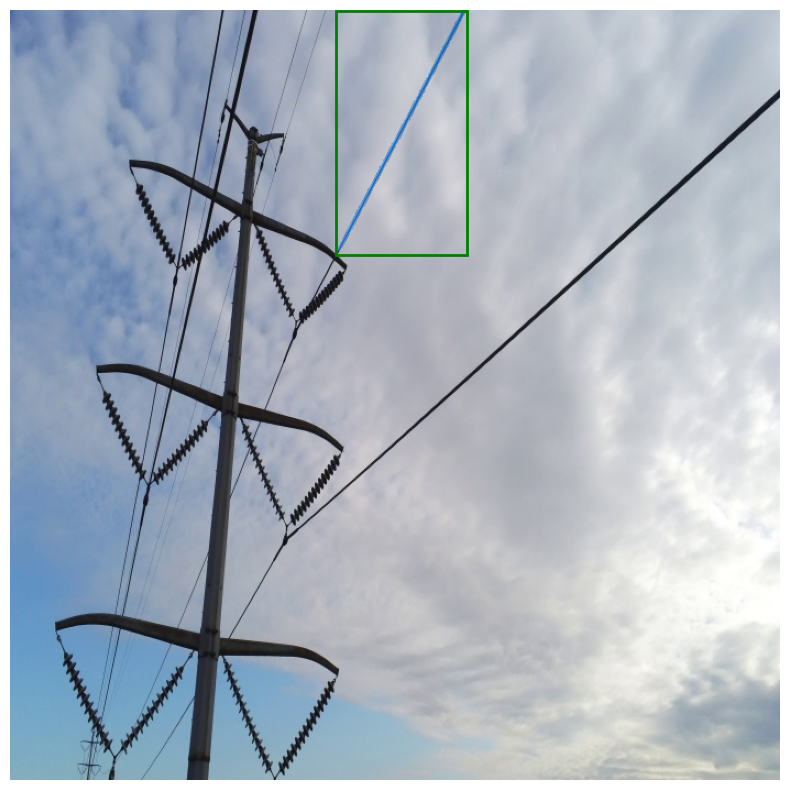

In [40]:
image = cv2.imread('/kaggle/input/cvdataset/testset/testset/31_7785.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
input_box = np.array(bbox)
input_point, input_label = None, None
predictor.set_image(image)
masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)

plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')
plt.show()